In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from river import tree
from river import metrics
from river import preprocessing

In [2]:
# Replace these with your actual file paths (CSV or Excel)
df = pd.read_csv("imputation_results_HAT.csv")

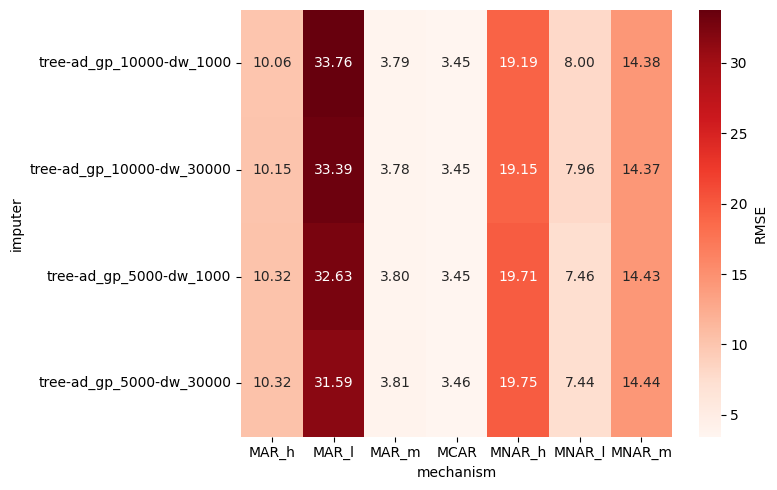

In [3]:
pivot = df.pivot_table(index='imputer', columns='mechanism', values='mean_rmse', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label': 'RMSE'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

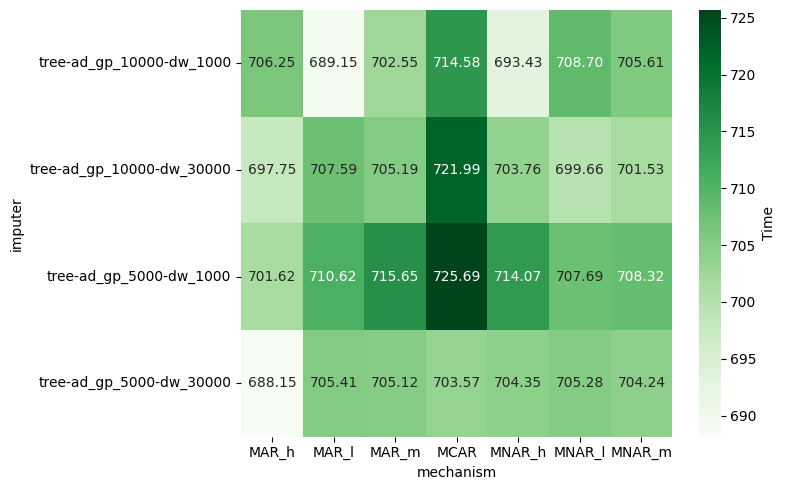

In [8]:
pivot = df.pivot_table(index='imputer', columns='mechanism', values='ac_time', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Greens', cbar_kws={'label': 'Time'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

In [4]:
import re

# Definir padrões seguros (regex ancorada)
method_patterns = {
    "KNN": r"^knn",
    "REG": r"^reg",
    "TREE": r"^tree(?!-ad)", 
    "HAT": r"^tree-ad",
    "MLP": r"^mlp",
    "MEAN": r"^mean"
}

# Calcular média de RMSE
avg_rmse = df.groupby('imputer')['mean_rmse'].mean()

best_imputers = []
print("Best model for each method:\n")

for method_name, pattern in method_patterns.items():
    
    method_imputers = [
        col for col in avg_rmse.index if re.search(pattern, col)
    ]
    
    if not method_imputers:
        continue
    
    best_model = avg_rmse.loc[method_imputers].idxmin()
    best_score = avg_rmse.loc[method_imputers].min()
    
    best_imputers.append(best_model)
    
    print(f"{method_name}: {best_model} (RMSE: {best_score:.2f})")

df_best = df[df['imputer'].isin(best_imputers)]

print(f"\nFiltered dataframe with best models: {len(df_best)} rows")


Best model for each method:

HAT: tree-ad_gp_5000-dw_30000 (RMSE: 12.97)

Filtered dataframe with best models: 35 rows


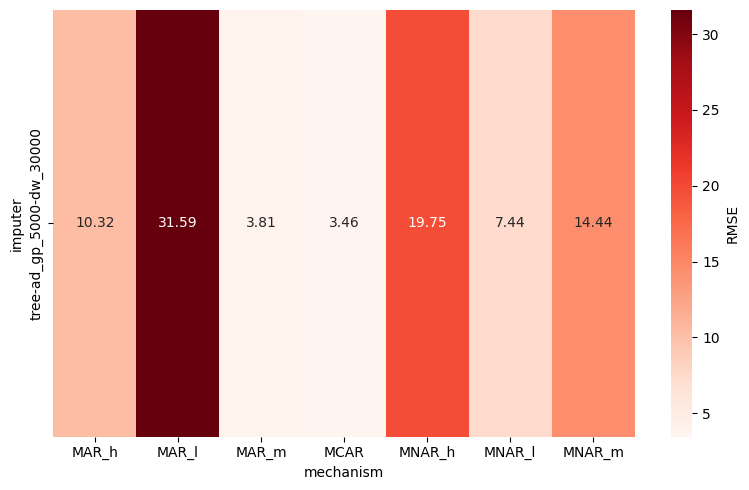

In [5]:
pivot = df_best.pivot_table(index='imputer', columns='mechanism', values='mean_rmse', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Reds', cbar_kws={'label': 'RMSE'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()

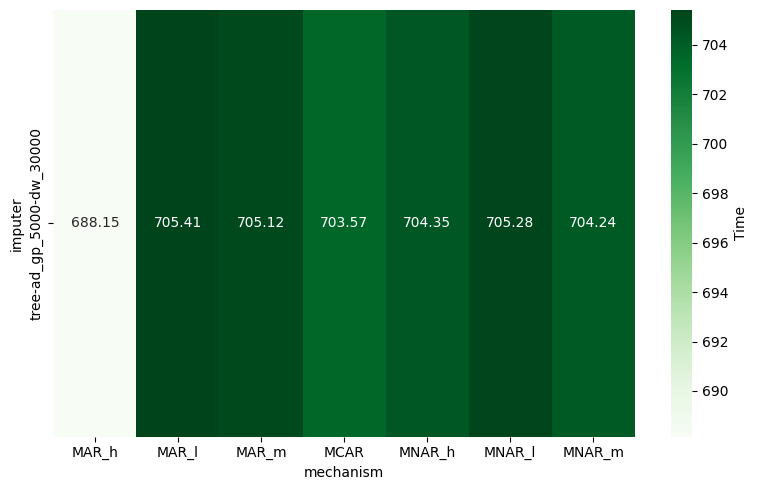

In [7]:
pivot = df_best.pivot_table(index='imputer', columns='mechanism', values='ac_time', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Greens', cbar_kws={'label': 'Time'})
plt.ylabel('imputer')
plt.xlabel('mechanism')
plt.tight_layout()
plt.show()